# Scikit learn linear regression + analytical matrix solution

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from utils import plot_cross_validation_performance


In [2]:
RANDOM_SEED = 42
TARGET_NAME = 'price'

In [3]:
df_train = pd.read_csv(Path('data') / '3 train_post_EDA.csv')
df_test = pd.read_csv(Path('data') / '3 test_post_EDA.csv')

display(df_train.head())
display(df_test.head())

,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


In [4]:
X_train = df_train.drop(columns=[TARGET_NAME])
y_train = df_train[TARGET_NAME]

X_test = df_test.drop(columns=[TARGET_NAME])
y_test = df_test[TARGET_NAME]

In [5]:
X_train = X_train.iloc[:-1]
y_train = y_train.iloc[:-1]

In [6]:
N_FOLDS = 24
kf = KFold(n_splits=N_FOLDS, shuffle=False)

cv_train_mses, cv_val_mses = [], []
cv_train_r2s, cv_val_r2s = [], []

for train_idx, val_idx in kf.split(X_train):
    # Split features and targets
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Initialize and fit model (Sklearn adds the intercept/ones column automatically)
    fold_model = LinearRegression(fit_intercept=True)
    fold_model.fit(X_tr, y_tr)

    # Collect log-scale predictions
    y_tr_pred = fold_model.predict(X_tr)
    y_va_pred = fold_model.predict(X_va)

    # Store standard metrics
    cv_train_mses.append(mean_squared_error(y_tr, y_tr_pred))
    cv_val_mses.append(mean_squared_error(y_va, y_va_pred))
    cv_train_r2s.append(r2_score(y_tr, y_tr_pred))
    cv_val_r2s.append(r2_score(y_va, y_va_pred))


print("📊 SKLEARN CROSS-VALIDATION PERFORMANCE (Instant Analytical Fits):")
print(f"  • Mean Validation MSE:  {np.mean(cv_val_mses):.4f}  (Train: {np.mean(cv_train_mses):.4f})")
print(f"  • Mean Validation RMSE: {np.sqrt(np.mean(cv_val_mses)):.4f}")
print(f"  • Mean Validation R²:   {np.mean(cv_val_r2s):.4f}  (Train: {np.mean(cv_train_r2s):.4f})\n")

📊 SKLEARN CROSS-VALIDATION PERFORMANCE (Instant Analytical Fits):
  • Mean Validation MSE:  0.0693  (Train: 0.0677)
  • Mean Validation RMSE: 0.2632
  • Mean Validation R²:   0.4231  (Train: 0.4992)



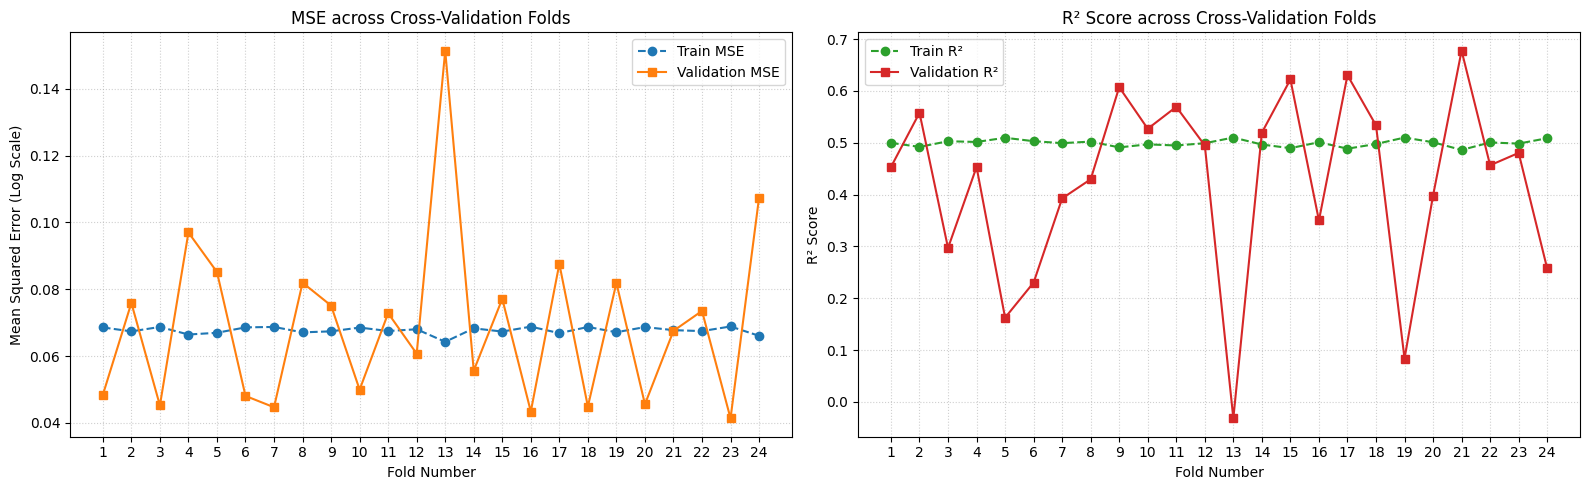

In [7]:
import matplotlib.pyplot as plt

# --- New Visualization for Scikit-Learn Analytical Folds ---
folds = np.arange(1, N_FOLDS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Left Plot: MSE per Fold
ax1.plot(folds, cv_train_mses, label='Train MSE', color='#1f77b4', marker='o', linestyle='--')
ax1.plot(folds, cv_val_mses, label='Validation MSE', color='#ff7f0e', marker='s', linestyle='-')
ax1.set_xlabel('Fold Number')
ax1.set_ylabel('Mean Squared Error (Log Scale)')
ax1.set_title('MSE across Cross-Validation Folds')
ax1.set_xticks(folds)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# 2. Right Plot: R² per Fold
ax2.plot(folds, cv_train_r2s, label='Train R²', color='#2ca02c', marker='o', linestyle='--')
ax2.plot(folds, cv_val_r2s, label='Validation R²', color='#d62728', marker='s', linestyle='-')
ax2.set_xlabel('Fold Number')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score across Cross-Validation Folds')
ax2.set_xticks(folds)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# fit_intercept=True means "do calculate bias"
final_model = LinearRegression(fit_intercept=True)
final_model.fit(X_train, y_train)

print("Final Weights Vector via Scikit-Learn Solver:")
print(f"- Intercept (w0):       {final_model.intercept_:.8f}")
print(f"- Feature Slopes (w):   {final_model.coef_}\n")

Final Weights Vector via Scikit-Learn Solver:
- Intercept (w0):       15.30269119
- Feature Slopes (w):   [0.17779436 0.06422505 0.11862864]



In [9]:
log_predictions = final_model.predict(X_test)

final_predictions_usd = np.exp(log_predictions)
final_actual_prices_usd = np.exp(y_test.to_numpy())

print("🏠 Sample Holdout Comparisons (First 5 Houses):")
for i in range(5):
    diff = final_predictions_usd[i] - final_actual_prices_usd[i]
    print(f"  • House {i+1}: Pred: ${final_predictions_usd[i]:,.2f} | Actual: ${final_actual_prices_usd[i]:,.2f} | Dev: ${diff:,.2f}")

🏠 Sample Holdout Comparisons (First 5 Houses):
  • House 1: Pred: $4,282,105.11 | Actual: $5,740,000.00 | Dev: $-1,457,894.89
  • House 2: Pred: $4,651,363.74 | Actual: $6,629,000.00 | Dev: $-1,977,636.26
  • House 3: Pred: $3,331,041.36 | Actual: $3,745,000.00 | Dev: $-413,958.64
  • House 4: Pred: $4,358,980.36 | Actual: $5,810,000.00 | Dev: $-1,451,019.64
  • House 5: Pred: $6,217,986.39 | Actual: $6,293,000.00 | Dev: $-75,013.61


In [10]:
absolute_errors = np.abs(final_predictions_usd - final_actual_prices_usd)
mae_usd = np.mean(absolute_errors)
median_error_usd = np.median(absolute_errors)
test_r2 = r2_score(final_actual_prices_usd, final_predictions_usd)

print("\n📊 FINAL HOLDOUT TEST SET PERFORMANCE SUMMARY:")
print(f"  • Mean Absolute Error (MAE):     ${mae_usd:,.2f}")
print(f"  • Median Absolute Error:         ${median_error_usd:,.2f}")
print(f"  • Final Test R² Score:           {test_r2:.4f}")


📊 FINAL HOLDOUT TEST SET PERFORMANCE SUMMARY:
  • Mean Absolute Error (MAE):     $1,001,589.51
  • Median Absolute Error:         $750,201.51
  • Final Test R² Score:           0.3874


**But why weights?** As we know from [[2 Derivatives, gradients and learning|the definition of derivatives]], they account for rates of change. As in the examples with other functions, why can't we just use the very definition of derivative to find the minimum? Based on the theory, we need to take the derivative and set it to $0$ for further analysis. As we said, the derivative:
> $$\begin{gather}
\nabla J(w) = \frac{1}{n}X^T(\hat y-y) \\
\frac{1}{n}X^T(\hat y-y)=0 /\cdot n \\
X^T(\hat y-y)=0, \text{where } \underbrace{\hat y=Xw}_{\text{Out goal is to isolate $w$}} \\
\end{gather}$$
> The bias in $\hat y$ was accounted for in $X$ as a col of $1$s. Then:
>$$\begin{gather}
X^T(Xw-y)=0 \\
X^TXw-X^Ty=0 \\
X^TXw=X^Ty \text{ (getting rid of $0$)}
\end{gather}$$
> We <u>would</u> want to divide by $X^T$ here, but <u>matrix division doesn't exist</u>. We can only multiply it by an inverted matrix: $\frac{1}{(X^T)}=(X^T)^{-1}$. However, <u>only square matrices are invertible</u>, which wouldn't make this formula universal. Therefore, we let the math bend us, we willingly create a square matrix with multiplying both parts by $(X^TX)^{-1}$, essentially making it a division. Whatever shapes they have (let's say 3x15 and 15x3, they will always converge to a square - 3x3). Then:
>$$\begin{gather}
X^TXw=X^Ty \space / \cdot (X^TX)^{-1} \\
w=(X^TX)^{-1}X^Ty
\end{gather}$$
>The resulting equation is called **the Normal Equation**.
>
> And it would still perform well on unseen data! It would yield the exact same weights. It even has the exact same problem being prone to overfitting <u>because of</u> being analytically perfect. **So what's the problem then?** The calculation of inverse matrix is.
> Computing a matrix inverse has a computational complexity of roughly $O(n^3)$, where $n$ is the number of features. If you have 100,000 features, <u>inverting that matrix once can crash your computer or take days</u>. *Gradient Descent* takes thousands of loops, but each loop only does simple multiplication ($O(mn)$), which is incredibly fast.

In [ ]:
# ----- 1. Add the manual 1s column to the training feature matrix to properly multiply with bias -----
fake_ones_feature = np.ones((X_train.shape[0], 1))
X_train_vector = np.concatenate((fake_ones_feature, X_train.to_numpy()), axis=1)    # X_train.to_numpy() converts dataframe into np.array
y_train_vector = y_train.to_numpy().reshape(-1, 1)                                  # y_train.to_numpy() converts dataframe into np.array, then .reshape(-1,1) forces the shape of (n_rows, 1 column)

# 2. Compute using the Normal Equation
w_analytical = np.linalg.inv(X_train_vector.T @ X_train_vector) @ X_train_vector.T @ y_train_vector

print("PURE NUMPY ANALYTICAL SOLUTION MATRIX:")
print(w_analytical)

PURE NUMPY ANALYTICAL SOLUTION MATRIX:
[[15.30269119]
 [ 0.17779436]
 [ 0.06422505]
 [ 0.11862864]]


📐 PURE NUMPY ANALYTICAL SOLUTION MATRIX:
[[15.30269119]
 [ 0.17779436]
 [ 0.06422505]
 [ 0.11862864]]